In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [ ]:
PROCESSED = '../../data/processed'

FEATURES_AVG = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
                'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu',
                'is_holiday', 'is_weekend',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]
FEATURES_REG = WEATHER_COLS + ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

TARGET = 'load_mw'

In [ ]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f'{name}')
    print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
    print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
    print(f'  R2    {r2:.4f}')
    print()
    return pred

In [ ]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_scaler.json') as f:
    scaler = json.load(f)
    
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
14 input features


In [12]:
X_train = train[FEATURES_AVG]
X_test  = test[FEATURES_AVG]
y_train = train[TARGET]
y_test  = test[TARGET]

lr = LinearRegression().fit(X_train, y_train)
pred = evaluate('Linear Regression (weather only, averaged)', lr, X_test, y_test)

Linear Regression (weather only, averaged)
  RMSE  0.5741  (2750 MW)
  MAE   0.4479  (2145 MW)
  R2    0.6504



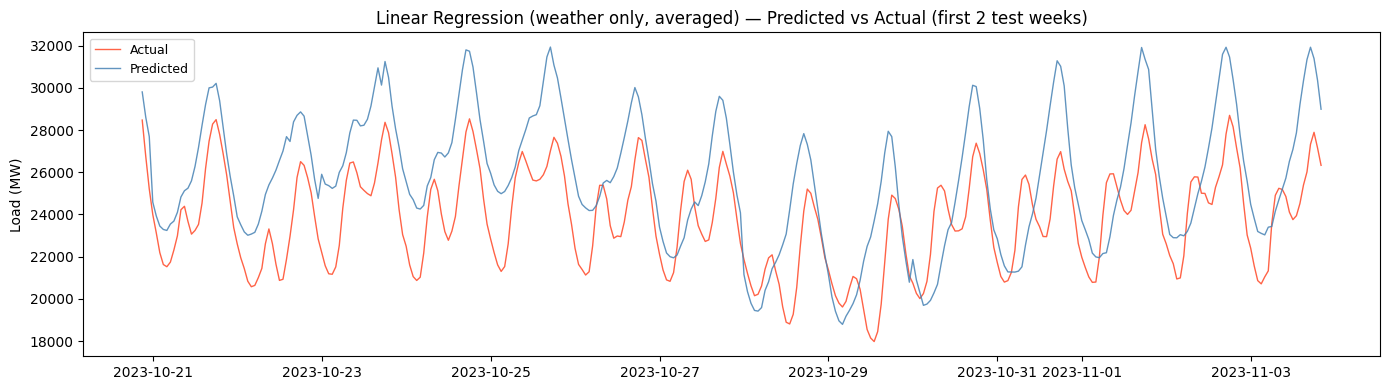

In [ ]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_test.values[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', linewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='Predicted')
ax.set_ylabel('Load (MW)')
ax.set_title('Linear Regression (weather only, averaged) — Predicted vs Actual (first 2 test weeks)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

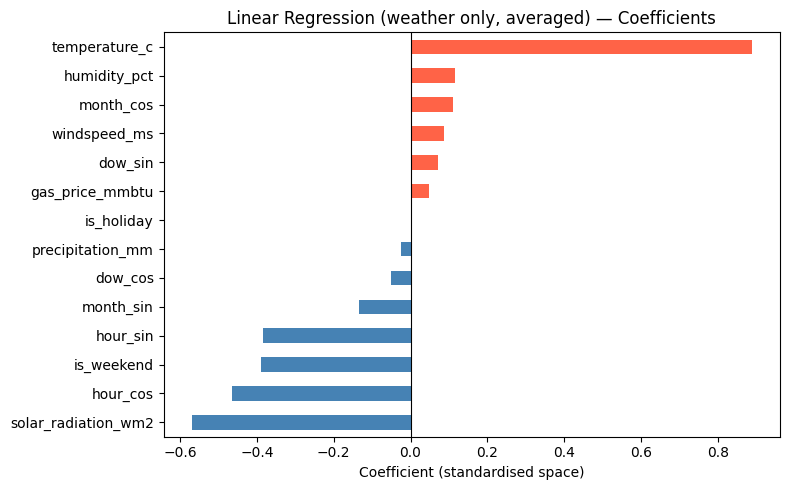

In [14]:
coef = pd.Series(lr.coef_, index=FEATURES_AVG).sort_values()
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]

fig, ax = plt.subplots(figsize=(8, 5))
coef.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression (weather only, averaged) — Coefficients')
ax.set_xlabel('Coefficient (standardised space)')
plt.tight_layout()
plt.show()

## Regional

In [15]:
train = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_train.csv', parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(f'{PROCESSED}/combined_hourly_regional_test.csv',  parse_dates=['datetime'], index_col='datetime')

with open(f'{PROCESSED}/combined_hourly_regional_scaler.json') as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(FEATURES_REG)} input features')

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
29 input features


In [16]:
X_train = train[FEATURES_REG]
X_test  = test[FEATURES_REG]
y_train = train[TARGET]
y_test  = test[TARGET]

lr = LinearRegression().fit(X_train, y_train)
pred = evaluate('Linear Regression (weather only, regional)', lr, X_test, y_test)

Linear Regression (weather only, regional)
  RMSE  0.5134  (2459 MW)
  MAE   0.4019  (1925 MW)
  R2    0.7205



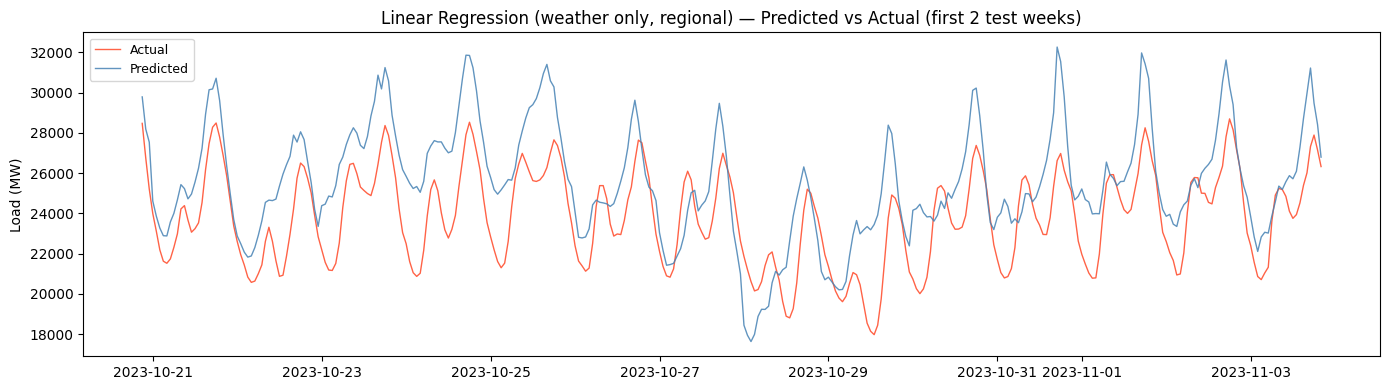

In [ ]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_test.values[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual, color='tomato', inewidth=1, label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='Predicted')
ax.set_ylabel('Load (MW)')
ax.set_title('Linear Regression (weather only, regional) — Predicted vs Actual (first 2 test weeks)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

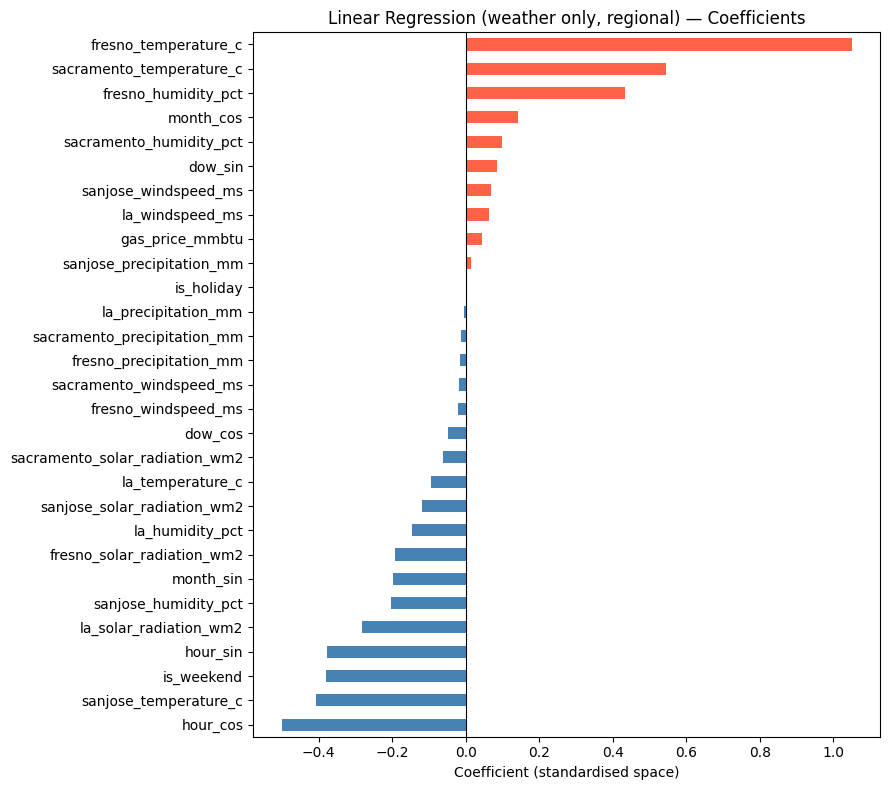

In [18]:
coef = pd.Series(lr.coef_, index=FEATURES_REG).sort_values()
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]

fig, ax = plt.subplots(figsize=(9, 8))
coef.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression (weather only, regional) — Coefficients')
ax.set_xlabel('Coefficient (standardised space)')
plt.tight_layout()
plt.show()